In [4]:
from pathlib import Path
import os

from dotenv import load_dotenv
import mysql.connector
import pandas as pd

# Giả sử notebook nằm ở thư mục gốc project:
project_root = Path.cwd()   # thư mục hiện tại của notebook
load_dotenv(project_root / ".env")

db_config = {
    "host": os.environ.get("DB_HOST", "localhost"),
    "user": os.environ.get("DB_USER"),
    "password": os.environ.get("DB_PASSWORD"),
    "database": os.environ.get("DB_NAME", "election_db"),
}

db_config

{'host': 'localhost',
 'user': 'root',
 'password': '170426',
 'database': 'election_db'}

In [7]:
import mysql.connector
import pandas as pd

conn = mysql.connector.connect(**db_config)

query = """
SELECT
    ep.CandidateID,
    ep.PredictionDate,
    ep.PredictedSupportRate,
    ep.ConfidenceLevel
FROM ElectionPredictions ep
ORDER BY ep.PredictionDate, ep.CandidateID;
"""

df = pd.read_sql(query, conn)
conn.close()

df.head()

C:\Users\HP\AppData\Local\Temp\ipykernel_8984\182882428.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,CandidateID,PredictionDate,PredictedSupportRate,ConfidenceLevel
0,1,2026-03-12,16.500000,200.0
1,1,2026-03-12,-0.446667,30.0
2,2,2026-03-12,37.500000,30.0
3,2,2026-03-12,-0.250000,3.0
4,3,2026-03-12,7.500000,20.0


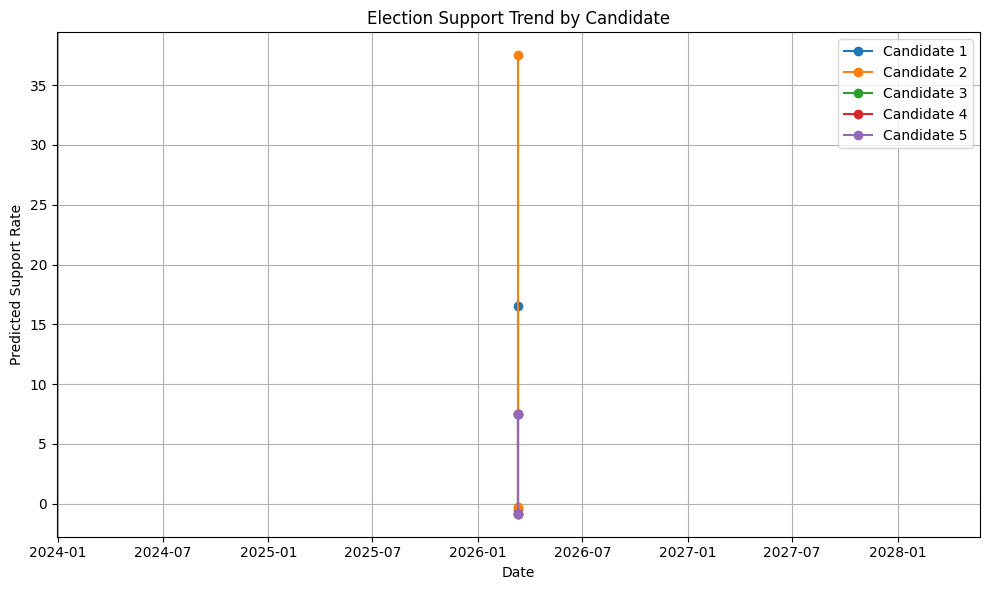

In [ ]:
import matplotlib.pyplot as plt

df["PredictionDate"] = pd.to_datetime(df["PredictionDate"])

plt.figure(figsize=(10, 6))

for candidate_id, group in df.groupby("CandidateID"):
    plt.plot(
        group["PredictionDate"],
        group["PredictedSupportRate"],
        marker="o",
        label=f"Candidate {candidate_id}",
    )

plt.xlabel("Date")
plt.ylabel("Predicted Support Rate")
plt.title("Election Support Trend by Candidate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
